# 15. Monoclonal antibody fed-batch co-design

A biopharmaceutical company has to deliver a monoclonal antibody at a target titer (g/L) and annual demand (kg/year). The design choices coupled cyclically are:

- **cell line**: which CHO clone to use (productivity, batch length, oxygen demand)
- **media**: which commercial formulation (cost per litre, max supported cell density)
- **bioreactor**: which format and size (single-use vs stainless steel, kLa cap)
- **feed strategy**: how aggressively to feed glucose (titer vs metabolic waste, batch failure risk)

The cycles are real biology: higher titer needs higher cell density, which needs higher kLa (more capable bioreactor), which the media must support. Richer feed produces more lactate and ammonia, which inflates the cell density required to deliver the same titer (closing the loop). The Kleene iteration converges this automatically.

All parameters are taken from the 2024-2026 bioprocessing literature: cell-line specific productivity (Reinhart 2021, Sumi 2024), oxygen uptake rates (BioProcess International 2024), media costs (CHO media market 2025), bioreactor capex (Sustainability Atlas 2026, BioPlan 2025), metabolic constraints (Khattak 2010, Lao & Toth 1997).


## Imports

In [1]:
import math
from codesign import (
    CatalogDP, CatalogEntry, Module, Ports, Reals,
    System, solve, viz,
)
import matplotlib.pyplot as plt

## Catalogue parameters

Each cell line is characterised by an *effective integrated* specific productivity (calibrated so titer = qP * avg_VCD * batch_days / 1000 gives realistic numbers at literature-reported peak VCDs of 10-30 million cells/mL).

The media list spans HyClone-CD (workhorse standard), EX-CELL-CD-CHO and Cellvento-CHO-220 (Sigma/Merck modern CD), and BalanCD-HIP (high-intensity perfusion grade). The bioreactor list spans single-use 200L through stainless steel 25,000L, with kLa caps mapped to maximum supportable peak VCD via the rule "kLa=1 supports about 4 million cells/mL with pure O2 sparging."


In [2]:
# (name, qP_eff [pg/cell/day], qO2 [1e-10 mmol/cell/h], batch_days, license [USD/batch])
CELL_LINES = [
    ("CHO-S",     15.0, 5.0, 14.0,    500.0),   # biomass-favouring legacy
    ("CHO-DG44",  18.0, 6.0, 14.0,   1500.0),   # DHFR-amplified, mid-tier
    ("CHO-K1",    50.0, 7.0, 12.0,   5000.0),   # high-producer workhorse
    ("CHO-MK",   120.0, 7.5,  8.0,  25000.0),   # next-gen, short batch
]

# (name, cost [USD/L], max_vcd_supported [1e6 cells/mL])
MEDIA_OPTIONS = [
    ("HyClone-CD",         80.0, 15.0),
    ("EX-CELL-CD-CHO",    110.0, 25.0),
    ("Cellvento-CHO-220", 140.0, 35.0),
    ("BalanCD-HIP",       250.0, 80.0),    # premium HIP grade
]

# (name, working_vol [L], max_peak_vcd [1e6 cells/mL], capex [USD/batch],
#  footprint [m^2], co2_per_batch [kg])
BIOREACTORS = [
    ("SU-200",     200.0,  40.0,   3_000.0,  2.0,  150.0),
    ("SU-2000",   2000.0,  60.0,  20_000.0,  8.0, 1200.0),    # industry sweet spot
    ("SS-5000",   5000.0,  72.0,  35_000.0, 12.0, 2200.0),
    ("SS-12500", 12500.0,  80.0,  60_000.0, 22.0, 4800.0),
    ("SS-25000", 25000.0,  90.0, 100_000.0, 35.0, 8500.0),
]

## The four subsystems

Each is a small Module or CatalogDP. The cell line maps a titer demand to a required cell density and oxygen demand; the bioreactor and media catalogues pick the smallest entry satisfying the (metabolically-inflated) cell-density demand; the feed strategy emits a U-shaped COGS multiplier capturing batch failure risk.


In [3]:
class CellLine(Module):
    # See the example's docstring for the unit derivation. With qP in
    # pg/cell/day and avg VCD in 1e6 cells/mL, titer = qP * avg_VCD *
    # batch_days * 1e-3 g/L, so avg_VCD = titer * 1e3 / (qP * batch_days).
    F = {"target_titer": Reals(unit="g/L")}
    R = {
        "avg_vcd":           Reals(unit="1e6 cells/mL"),
        "peak_vcd":          Reals(unit="1e6 cells/mL"),
        "oxygen_demand":     Reals(unit="mmol/L/h"),
        "batch_days":        Reals(unit="day"),
        "license_per_batch": Reals(unit="USD"),
    }

    def __init__(self, name, qp, qo2, batch_days, license_fee, peak_to_avg=2.0):
        self.cell_name = name
        self.qp = qp                 # effective integrated qP, pg/cell/day
        self.qo2 = qo2               # 1e-10 mmol/cell/h
        self.batch_days = batch_days
        self.license_fee = license_fee
        self.peak_to_avg = peak_to_avg
        super().__init__()

    def h(self, f):
        titer = f["target_titer"]
        avg_vcd  = titer * 1e3 / (self.qp * self.batch_days)
        peak_vcd = self.peak_to_avg * avg_vcd
        # OUR_peak = peak_VCD [1e6 cells/mL] * 1e9 cells/L * qO2 * 1e-10 mmol/cell/h
        #          = peak_VCD_million * qO2 * 0.1
        oxygen = peak_vcd * self.qo2 * 0.1
        return {
            "avg_vcd": avg_vcd, "peak_vcd": peak_vcd,
            "oxygen_demand": oxygen,
            "batch_days": float(self.batch_days),
            "license_per_batch": float(self.license_fee),
        }

In [4]:
def make_bioreactor_dp():
    # CatalogDP that picks the smallest bioreactor supporting the
    # demanded peak VCD. Costs are per-batch; the working volume is
    # an output we use later to compute COGS per gram.
    F = Ports({"peak_vcd": Reals(unit="1e6 cells/mL")})
    R = Ports({
        "working_volume":  Reals(unit="L"),
        "capex_per_batch": Reals(unit="USD"),
        "footprint_m2":    Reals(unit="m^2"),
        "co2_per_batch":   Reals(unit="kg"),
    })
    entries = [
        CatalogEntry(
            name=name,
            provides={"peak_vcd": max_vcd},
            costs={"working_volume": vol, "capex_per_batch": capex,
                   "footprint_m2": fp, "co2_per_batch": co2},
        )
        for (name, vol, max_vcd, capex, fp, co2) in BIOREACTORS
    ]
    return CatalogDP(F=F, R=R, catalog=entries, name="bioreactors")


def make_media_dp():
    # CatalogDP that picks the cheapest media supporting the peak VCD.
    F = Ports({"peak_vcd": Reals(unit="1e6 cells/mL")})
    R = Ports({"media_cost_per_l": Reals(unit="USD/L")})
    entries = [
        CatalogEntry(
            name=name,
            provides={"peak_vcd": max_vcd},
            costs={"media_cost_per_l": cost},
        )
        for (name, cost, max_vcd) in MEDIA_OPTIONS
    ]
    return CatalogDP(F=F, R=R, catalog=entries, name="media")


class FeedStrategy(Module):
    # The single design knob is the glucose set-point in mM.
    # Lower (around 5 mM) = HIPDOG-style, minimises lactate/ammonia
    # but harder to control near starvation threshold.
    # Higher (around 12-15 mM) = legacy, easier to control but produces
    # more waste, reducing growth (Khattak 2010).
    # The COGS multiplier captures U-shaped batch-failure risk.
    F = {"peak_vcd": Reals(unit="1e6 cells/mL"),
         "batch_days": Reals(unit="day")}
    R = {"feed_cost_per_l":  Reals(unit="USD/L"),
         "metabolic_factor": Reals(unit="rel"),
         "cogs_multiplier":  Reals(unit="rel")}

    def __init__(self, glucose_setpoint_mm=8.0):
        self.glucose = max(4.0, min(15.0, float(glucose_setpoint_mm)))
        super().__init__()

    def h(self, f):
        glucose_premium = 1.0 + 0.05 * (self.glucose - 5.0)
        feed_cost_per_l = 6.0 * glucose_premium * f["batch_days"] * 0.05
        # Khattak's correlation: ~+30% waste from 3x nutrient.
        waste_factor = 1.0 + 0.03 * (self.glucose - 5.0)
        # U-shape: low glucose risks starvation, high glucose risks waste.
        low_penalty  = 0.06  * max(0.0, 8.0 - self.glucose) ** 1.5
        high_penalty = 0.015 * max(0.0, self.glucose - 8.0) ** 1.5
        return {
            "feed_cost_per_l":  feed_cost_per_l,
            "metabolic_factor": waste_factor,
            "cogs_multiplier":  1.0 + low_penalty + high_penalty,
        }

## Assemble the system

The outer F is the target titer; the outer R is the cost vector (COGS, footprint, CO2). The COGS expression integrates capex, license fee, media, feed cost, and the U-shaped batch-failure multiplier. Footprint depends on the annual demand (more demand needs more parallel reactor lines).


In [5]:
def make_bioprocess(*, cell_line, glucose_setpoint_mm,
                    annual_demand_kg, turnaround_days=5.0,
                    downstream_yield=0.7):
    sys = System(f"mAb_{cell_line[0]}")
    # Outer F: titer demand at harvest.
    target_titer = sys.provides("target_titer", unit="g/L")
    # Outer R: three-way cost vector for the engineer.
    sys.requires("cogs_per_g",   unit="USD/g")
    sys.requires("footprint_m2", unit="m^2")
    sys.requires("co2_per_g",    unit="kg/g")

    # Subsystems.
    cell  = sys.add("cell",  CellLine(*cell_line))
    feed  = sys.add("feed",  FeedStrategy(glucose_setpoint_mm))
    bior  = sys.add("bior",  make_bioreactor_dp())
    media = sys.add("media", make_media_dp())

    # Wiring: titer demand drives required cell density; feed strategy
    # inflates it by the metabolic factor; bioreactor and media must
    # both support the inflated peak VCD.
    cell.target_titer >= target_titer
    feed.peak_vcd     >= cell.peak_vcd
    feed.batch_days   >= cell.batch_days
    bior.peak_vcd     >= cell.peak_vcd * feed.metabolic_factor
    media.peak_vcd    >= cell.peak_vcd * feed.metabolic_factor

    # Outer R aggregation. We use the dict-based constrain form because
    # we need to combine several ports with closed-over parameters
    # (annual_demand_kg, downstream_yield, turnaround_days).
    def cogs_eq(x):
        vol = x["bior.working_volume"]
        mass_per_batch_g = x["target_titer"] * vol * downstream_yield
        cost_per_batch = (x["bior.capex_per_batch"]
                          + x["cell.license_per_batch"]
                          + x["media.media_cost_per_l"] * vol
                          + x["feed.feed_cost_per_l"] * vol)
        # Multiply by feed-strategy COGS multiplier for batch-failure risk.
        return (cost_per_batch / max(mass_per_batch_g, 1e-6)
                * x["feed.cogs_multiplier"])

    def footprint_eq(x):
        # Annual demand / per-batch mass = batches/year needed.
        # Each line delivers 365/(batch+turnaround) batches/year.
        # 3x multiplier for downstream and utilities space.
        vol = x["bior.working_volume"]
        cycle_d = x["cell.batch_days"] + turnaround_days
        max_batches_per_line = 365.0 / cycle_d
        mass_per_batch_g = x["target_titer"] * vol * downstream_yield
        batches_needed = annual_demand_kg * 1000.0 / max(mass_per_batch_g, 1e-6)
        parallel_lines = max(1.0, batches_needed / max_batches_per_line)
        return parallel_lines * x["bior.footprint_m2"] * 3.0

    def co2_eq(x):
        vol = x["bior.working_volume"]
        mass_per_batch_g = x["target_titer"] * vol * downstream_yield
        return x["bior.co2_per_batch"] / max(mass_per_batch_g, 1e-6)

    sys.constrain("cogs_per_g",   cogs_eq)
    sys.constrain("footprint_m2", footprint_eq)
    sys.constrain("co2_per_g",    co2_eq)
    return sys.build()

## Solve for a single scenario

A 100 kg/year mid-stage commercial program at 5 g/L titer with CHO-K1 and 8 mM glucose.


In [6]:
dp = make_bioprocess(
    cell_line=CELL_LINES[2],            # CHO-K1
    glucose_setpoint_mm=8.0,
    annual_demand_kg=100.0,
)
result = solve(dp, {"target_titer": 5.0}, max_iter=200)
print(f"status: {result.status}, feasible: {result.feasible}, "
      f"iters: {result.iterations}")
for p in result.antichain.points:
    print(f"   COGS      = ${p['cogs_per_g']:.2f}/g")
    print(f"   Footprint = {p['footprint_m2']:.1f} m^2")
    print(f"   CO2       = {p['co2_per_g']*1000:.1f} g CO2/g mAb")

status: converged, feasible: True, iters: 3
   COGS      = $44.04/g
   Footprint = 39.9 m^2
   CO2       = 214.3 g CO2/g mAb


## Sweep across cell lines and feed strategies

For each cell-line / glucose-setpoint combination, solve and collect the (COGS, footprint, CO2) point. Compute the global Pareto front across all 12 design combinations.


In [7]:
def sweep(target_titer, annual_demand):
    # Every (cell_line, glucose) combination yields one design point.
    results = []
    for cl in CELL_LINES:
        for glu in (5.0, 8.0, 12.0):
            dp = make_bioprocess(cell_line=cl, glucose_setpoint_mm=glu,
                                 annual_demand_kg=annual_demand)
            r = solve(dp, {"target_titer": target_titer}, max_iter=200)
            if not r.feasible:
                continue
            for pt in r.antichain.points:
                if math.isinf(pt["cogs_per_g"]):
                    continue
                results.append({
                    "cell": cl[0], "glu": glu,
                    "label": f"{cl[0]}/glu={glu:.0f}mM",
                    "cogs": pt["cogs_per_g"],
                    "fp": pt["footprint_m2"],
                    "co2": pt["co2_per_g"],
                })
    # Global 3D Pareto front: a point is non-dominated if no other
    # point is <= in all three R components and strictly < in any.
    pareto = []
    for p in results:
        dominated = any(
            q["cogs"] <= p["cogs"] and q["fp"] <= p["fp"] and q["co2"] <= p["co2"]
            and (q["cogs"] < p["cogs"] or q["fp"] < p["fp"] or q["co2"] < p["co2"])
            for q in results
        )
        if not dominated:
            pareto.append(p)
    return results, sorted(pareto, key=lambda x: x["cogs"])

results, pareto = sweep(5.0, 100.0)
print(f"\n100 kg/yr at 5 g/L: {len(results)} feasible designs, "
      f"{len(pareto)} on the Pareto front:")
for p in pareto:
    print(f"   {p['label']:<25} COGS=${p['cogs']:5.2f}/g  "
          f"footprint={p['fp']:5.1f} m^2  CO2={p['co2']*1000:.1f} g/g")


100 kg/yr at 5 g/L: 7 feasible designs, 2 on the Pareto front:
   CHO-K1/glu=8mM            COGS=$44.04/g  footprint= 39.9 m^2  CO2=214.3 g/g
   CHO-MK/glu=8mM            COGS=$63.65/g  footprint= 30.5 m^2  CO2=214.3 g/g


## Visualise the Pareto front

A 2D scatter in (COGS, footprint) space. All evaluated designs in grey; the Pareto-optimal ones in red. The shape of the front reveals the real engineering tradeoff: shorter-batch high-producer cell lines (CHO-MK) win on footprint but pay more per gram in licence fees; longer-batch standard cell lines (CHO-K1) win on COGS but need more parallel lines for the same annual output.


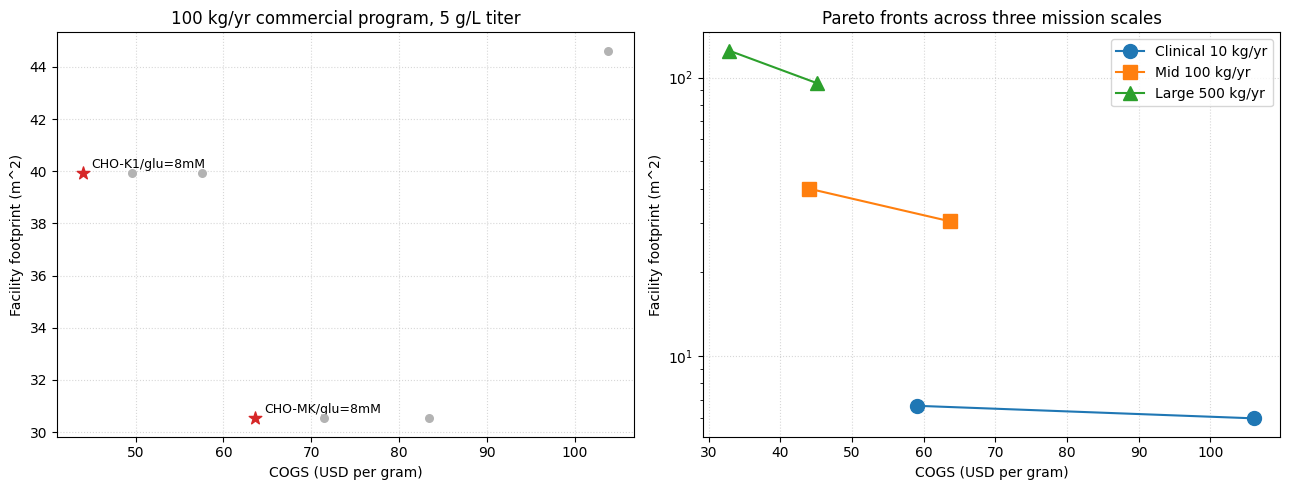

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: full design space + Pareto front.
ax = axes[0]
pareto_keys = {(p["cell"], p["glu"]) for p in pareto}
for r in results:
    color = "C3" if (r["cell"], r["glu"]) in pareto_keys else "0.7"
    size = 90 if (r["cell"], r["glu"]) in pareto_keys else 30
    marker = "*" if (r["cell"], r["glu"]) in pareto_keys else "o"
    ax.scatter(r["cogs"], r["fp"], c=color, s=size, marker=marker, zorder=3)
    if (r["cell"], r["glu"]) in pareto_keys:
        ax.annotate(r["label"], (r["cogs"], r["fp"]),
                    xytext=(6, 4), textcoords="offset points", fontsize=9)
ax.set_xlabel("COGS (USD per gram)")
ax.set_ylabel("Facility footprint (m^2)")
ax.set_title("100 kg/yr commercial program, 5 g/L titer")
ax.grid(True, linestyle=":", alpha=0.5)

# Right panel: Pareto fronts for three mission scales.
ax = axes[1]
for label, titer, demand, marker in [
    ("Clinical 10 kg/yr",   3.0,  10.0, "o"),
    ("Mid 100 kg/yr",       5.0, 100.0, "s"),
    ("Large 500 kg/yr",     8.0, 500.0, "^"),
]:
    _, pf = sweep(titer, demand)
    xs = [p["cogs"] for p in pf]
    ys = [p["fp"] for p in pf]
    ax.plot(xs, ys, marker=marker, label=label, markersize=10, linewidth=1.5)
ax.set_xlabel("COGS (USD per gram)")
ax.set_ylabel("Facility footprint (m^2)")
ax.set_yscale("log")
ax.set_title("Pareto fronts across three mission scales")
ax.legend()
ax.grid(True, linestyle=":", alpha=0.5)

fig.tight_layout()
plt.show()

## What the framework just did

The Kleene iteration resolved the cyclic constraints automatically. The cycle that matters:

1. The CellLine module sees the titer demand and emits a peak VCD.
2. FeedStrategy reads that VCD and emits a metabolic factor.
3. The Bioreactor catalogue must support `peak_vcd * metabolic_factor`, which is larger than the bare cell-line demand.
4. Inside the catalogue lookup, the smallest sufficient bioreactor is chosen, with its own kLa cap acting as a feasibility wall.

The Pareto front is genuinely two-point in every scenario. CHO-K1 with 12-day batches is cheap per gram but needs more parallel lines for high annual demand, occupying more floor space. CHO-MK with 8-day batches has expensive licence fees per batch but turns over twice as often, so the same annual output fits in fewer parallel lines and less footprint. CHO-S and CHO-DG44 are dominated everywhere because their lower productivity demands more cells and more bioreactor volume, raising both COGS and footprint together.

The framework would extend in several useful directions: adding a perfusion mode subsystem (essentially a Loop with much higher peak VCD but continuous media exchange), modelling product quality attributes (glycosylation profile, aggregation rate) as additional R components, adding regulatory uncertainty as a UncertainDP wrapper, or running the same problem with `solve_online` to design an experimental campaign that finds the Pareto front in 20 to 30 bench runs rather than 200 to 500.
